# Week 5: Hormone receptor status and demographic patterns

This notebook completes the exploratory analysis of age, race, and marital status by estrogen receptor (ER), progesterone receptor (PR), and joint ER/PR status. It includes data checks, descriptive tables, nine visualizations, association tests, findings, and preparation for Streamlit integration.

**Run from top to bottom.** All analysis functions are included here; no project Python modules are required. The notebook reads `dataset/seer_breast_cancer_cleaned.csv` from the project folder; keep the dataset folder alongside the notebook. Saved outputs allow the results to be reviewed without running the notebook.

Dependencies: Python 3.9+, pandas >=2.2, numpy >=1.26, scipy >=1.12, matplotlib >=3.9. For execution, use a Jupyter kernel with these packages. Optional Streamlit export additionally requires streamlit >=1.40.

In [1]:
from pathlib import Path
import io
import json
import textwrap
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
DATA_PATH = ROOT / "dataset/seer_breast_cancer_cleaned.csv"
RECEPTORS = ["Estrogen Status", "Progesterone Status", "Receptor Group"]
DEMOGRAPHICS = ["Race", "Marital Status"]
GROUP_ORDER = ["ER+/PR+", "ER+/PR−", "ER−/PR+", "ER−/PR−"]
pd.set_option("display.max_columns", None)
print("Package versions:", {"pandas": pd.__version__, "numpy": np.__version__, "scipy": __import__("scipy").__version__, "matplotlib": matplotlib.__version__})

Package versions: {'pandas': '2.3.3', 'numpy': '2.0.2', 'scipy': '1.13.1', 'matplotlib': '3.9.4'}


## 1. Load and validate the data

Receptor labels must be Positive or Negative. Age is converted to numeric and checked for plausible values. Clinical characteristics such as stage and tumor size are not treated as demographic features. No records are deduplicated because patient identifiers are unavailable.

In [2]:
def load_data(path=ROOT / "dataset/seer_breast_cancer_cleaned.csv"):
    df = pd.read_csv(path)
    required = ["Age", *DEMOGRAPHICS, "Estrogen Status", "Progesterone Status"]
    missing = set(required) - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")
    for col in required[1:]:
        df[col] = df[col].astype("string").str.strip().replace("", pd.NA)
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
    if ((df["Age"] < 0) | (df["Age"] > 120)).any():
        raise ValueError("Age outside plausible range 0–120.")
    for col in ["Estrogen Status", "Progesterone Status"]:
        unexpected = set(df[col].dropna().unique()) - {"Positive", "Negative"}
        if unexpected:
            raise ValueError(f"Unexpected {col}: {unexpected}")
    er = df["Estrogen Status"].map({"Positive": "+", "Negative": "−"})
    pr = df["Progesterone Status"].map({"Positive": "+", "Negative": "−"})
    df["Receptor Group"] = "ER" + er + "/PR" + pr
    return df

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}. Run this notebook from the project folder with the dataset folder alongside it.")
print("Data source:", DATA_PATH)
df = load_data(DATA_PATH)
print(f"Records: {len(df):,}; columns: {len(df.columns)}")
display(df.head())

Data source: /Users/stew/course_project/cancer-survival-patterns/dataset/seer_breast_cancer_cleaned.csv
Records: 4,023; columns: 16


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Regional Node Positive,Survival Months,Status,Receptor Group
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),T2,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive,ER+/PR+
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),T2,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive,ER+/PR+
2,67,White,Married (including common law),T2,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead,ER+/PR+
3,46,White,Divorced,T1,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead,ER+/PR+
4,63,White,Married (including common law),T2,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead,ER+/PR+


## 2. Descriptive summaries and statistical methods

Age distributions are compared with two-sided Mann–Whitney U tests for individual receptors and Kruskal–Wallis for the four joint groups. These tests compare distributions, not strictly medians. Categorical variables use Pearson chi-square tests; any expected cell below five triggers a fixed-margin Monte Carlo p-value with 20,000 draws and a fixed seed.

Effect sizes are signed rank-biserial correlation (Negative minus Positive), epsilon-squared, and Cramér’s V, respectively. Benjamini–Hochberg correction covers the nine omnibus tests together. Comparisons are unadjusted for clinical variables and exploratory.

In [3]:
def bh_adjust(pvalues):
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p)
    adjusted = np.minimum.accumulate((p[order] * len(p) / np.arange(1, len(p)+1))[::-1])[::-1]
    result = np.empty_like(p)
    result[order] = np.minimum(adjusted, 1)
    return result

def summarize(df):
    quality = pd.DataFrame({"missing": df.isna().sum(), "unique_values": df.nunique()})
    ages, tables, tests = [], {}, []
    for receptor in RECEPTORS:
        subset = df.dropna(subset=[receptor, "Age"])
        groups = [g["Age"].to_numpy() for _, g in subset.groupby(receptor, sort=True)]
        for label, group in subset.groupby(receptor, sort=True):
            age = group["Age"]
            ages.append(dict(receptor=receptor, group=label, n=len(age), mean=age.mean(),
                             sd=age.std(), median=age.median(), q1=age.quantile(.25), q3=age.quantile(.75),
                             minimum=age.min(), maximum=age.max()))
        if len(groups) < 2 or any(len(g) == 0 for g in groups):
            raise ValueError(f"Insufficient groups for {receptor}")
        if len(groups) == 2:
            result = stats.mannwhitneyu(*groups, alternative="two-sided", method="asymptotic")
            effect = 2 * result.statistic / (len(groups[0])*len(groups[1])) - 1
            effect_name = "rank-biserial (first alphabetical group minus second)"
            method = "Mann–Whitney U"
        else:
            result = stats.kruskal(*groups)
            effect = max(0, (result.statistic-len(groups)+1)/(len(subset)-len(groups)))
            effect_name = "epsilon-squared"
            method = "Kruskal–Wallis"
        tests.append(dict(receptor=receptor, demographic="Age", test=method, n=len(subset),
                          statistic=result.statistic, p_value=result.pvalue, effect=effect,
                          effect_name=effect_name, minimum_expected=np.nan, sparse=False))
        for demographic in DEMOGRAPHICS:
            table = pd.crosstab(df[demographic], df[receptor])
            chi2, p, _, expected = stats.chi2_contingency(table)
            sparse = bool((expected < 5).any())
            # Fixed-margin Monte Carlo avoids unreliable asymptotics for sparse cells.
            if sparse:
                rng = np.random.default_rng(20261008)
                simulations = stats.random_table.rvs(table.sum(axis=1).to_numpy(),
                    table.sum(axis=0).to_numpy(), size=20000, random_state=rng)
                simulated_chi2 = ((simulations-expected)**2/expected).sum(axis=(1,2))
                p = (1 + (simulated_chi2 >= chi2-1e-10).sum()) / 20001
            n = int(table.to_numpy().sum())
            effect = np.sqrt(chi2/(n*min(table.shape[0]-1, table.shape[1]-1)))
            tests.append(dict(receptor=receptor, demographic=demographic,
                test="Pearson chi-square" + ("; fixed-margin Monte Carlo p (20,000 draws)" if sparse else ""),
                n=n, statistic=chi2, p_value=p, effect=effect, effect_name="Cramér's V",
                minimum_expected=expected.min(), sparse=sparse))
            tables[(receptor, demographic)] = table
    tests = pd.DataFrame(tests)
    tests["p_adjusted_bh"] = bh_adjust(tests.p_value)
    return quality, pd.DataFrame(ages), tables, tests

quality, ages, tables, tests = summarize(df)
display(quality)
print("Exact duplicate rows:", df.drop(columns="Receptor Group").duplicated().sum())
display(df["Age"].describe().to_frame("Age"))

,missing,unique_values
Age,0,40
Race,0,3
Marital Status,0,5
T Stage,0,4
N Stage,0,3
6th Stage,0,5
Grade,0,4
A Stage,0,2
Tumor Size,0,110
Estrogen Status,0,2


Exact duplicate rows: 0


,Age
count,4023.000000
mean,53.969923
std,8.963118
min,30.000000
25%,47.000000
50%,54.000000
75%,61.000000
max,69.000000


### Receptor group frequencies

In [4]:
receptor_counts = df["Receptor Group"].value_counts().reindex(GROUP_ORDER, fill_value=0)
receptor_summary = receptor_counts.to_frame("count")
receptor_summary["percent"] = 100 * receptor_summary["count"] / len(df)
display(receptor_summary.round(2))

,count,percent
Receptor Group,,
ER+/PR+,3298,81.98
ER+/PR−,456,11.33
ER−/PR+,27,0.67
ER−/PR−,242,6.02


### Age by receptor status

In [5]:
display(ages.round(3))

,receptor,group,n,mean,sd,median,q1,q3,minimum,maximum
0,Estrogen Status,Negative,269,51.970,9.244,53.0,46.0,59.00,30,69
1,Estrogen Status,Positive,3754,54.113,8.927,54.0,47.0,62.00,30,69
2,Progesterone Status,Negative,698,54.388,8.891,55.0,49.0,61.75,30,69
3,Progesterone Status,Positive,3325,53.882,8.977,54.0,47.0,61.00,30,69
4,Receptor Group,ER+/PR+,3298,53.917,8.974,54.0,47.0,61.00,30,69
5,Receptor Group,ER+/PR−,456,55.535,8.454,56.0,50.0,62.00,31,69
6,Receptor Group,ER−/PR+,27,49.667,8.544,50.0,43.0,56.00,35,65
7,Receptor Group,ER−/PR−,242,52.227,9.300,53.0,46.0,59.00,30,69


### Demographic counts and within-category percentages

Percentages use each race or marital-status category as the denominator, rather than the entire cohort.

In [6]:
for (receptor, demographic), table in tables.items():
    display(Markdown(f"#### {receptor} by {demographic}"))
    display(Markdown("**Counts**"))
    display(table)
    display(Markdown("**Percent within demographic category**"))
    display((table.div(table.sum(axis=1), axis=0) * 100).round(2))

#### Estrogen Status by Race

**Counts**

Estrogen Status,Negative,Positive
Race,,
Black,33,258
"Other (American Indian/AK Native, Asian/Pacific Islander)",27,293
White,209,3203


**Percent within demographic category**

Estrogen Status,Negative,Positive
Race,,
Black,11.34,88.66
"Other (American Indian/AK Native, Asian/Pacific Islander)",8.44,91.56
White,6.13,93.87


...

#### Receptor Group by Marital Status

**Counts**

Receptor Group,ER+/PR+,ER+/PR−,ER−/PR+,ER−/PR−
Marital Status,,,,
Divorced,392,67,4,23
Married (including common law),2183,286,20,153
Separated,30,8,0,7
Single (never married),506,62,3,44
Widowed,187,33,0,15


**Percent within demographic category**

Receptor Group,ER+/PR+,ER+/PR−,ER−/PR+,ER−/PR−
Marital Status,,,,
Divorced,80.66,13.79,0.82,4.73
Married (including common law),82.63,10.83,0.76,5.79
Separated,66.67,17.78,0.00,15.56
Single (never married),82.28,10.08,0.49,7.15
Widowed,79.57,14.04,0.00,6.38


## 3. Visualizations

Boxplots show age distributions, medians, and interquartile ranges. Stacked bar charts show receptor percentages within each demographic category. All charts include group denominators.

In [7]:
def make_figures(df):
    figures = {}
    for receptor in RECEPTORS:
        order = GROUP_ORDER if receptor == "Receptor Group" else ["Positive", "Negative"]
        order = [x for x in order if (df[receptor] == x).any()]
        fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
        arrays = [df.loc[df[receptor] == x, "Age"].dropna() for x in order]
        ax.boxplot(arrays, tick_labels=[f"{x}\n(n={len(a):,})" for x,a in zip(order, arrays)], patch_artist=True)
        ax.set(title=f"Age by {receptor.lower()}", ylabel="Age (years)", xlabel=receptor)
        figures[(receptor, "Age")] = fig
        for demographic in DEMOGRAPHICS:
            counts = pd.crosstab(df[demographic], df[receptor]).reindex(columns=order, fill_value=0)
            percentages = counts.div(counts.sum(axis=1), axis=0)*100
            fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
            percentages.plot.barh(stacked=True, ax=ax, color=["#277da8", "#f4a261", "#63ad95", "#bc5090"][:len(order)])
            labels = [f"{textwrap.fill(str(x), 35)}\n(n={int(n):,})" for x,n in zip(counts.index, counts.sum(axis=1))]
            ax.set_yticks(range(len(labels)), labels=labels)
            ax.set(xlim=(0,100), xlabel="Percent within demographic category", ylabel="",
                   title=f"{receptor} by {demographic.lower()}")
            ax.legend(title=receptor, loc="upper center", bbox_to_anchor=(.5,-.16), ncol=min(4,len(order)))
            figures[(receptor, demographic)] = fig
    return figures

def display_figure(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130)
    display(Image(data=buffer.getvalue()))

figures = make_figures(df)

### Estrogen Status

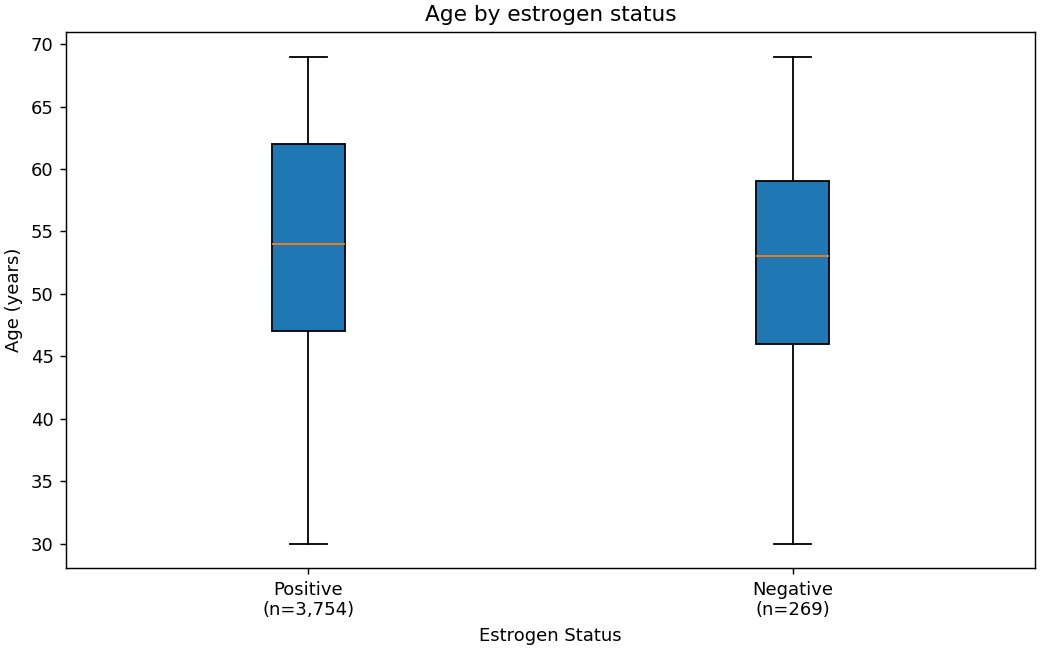

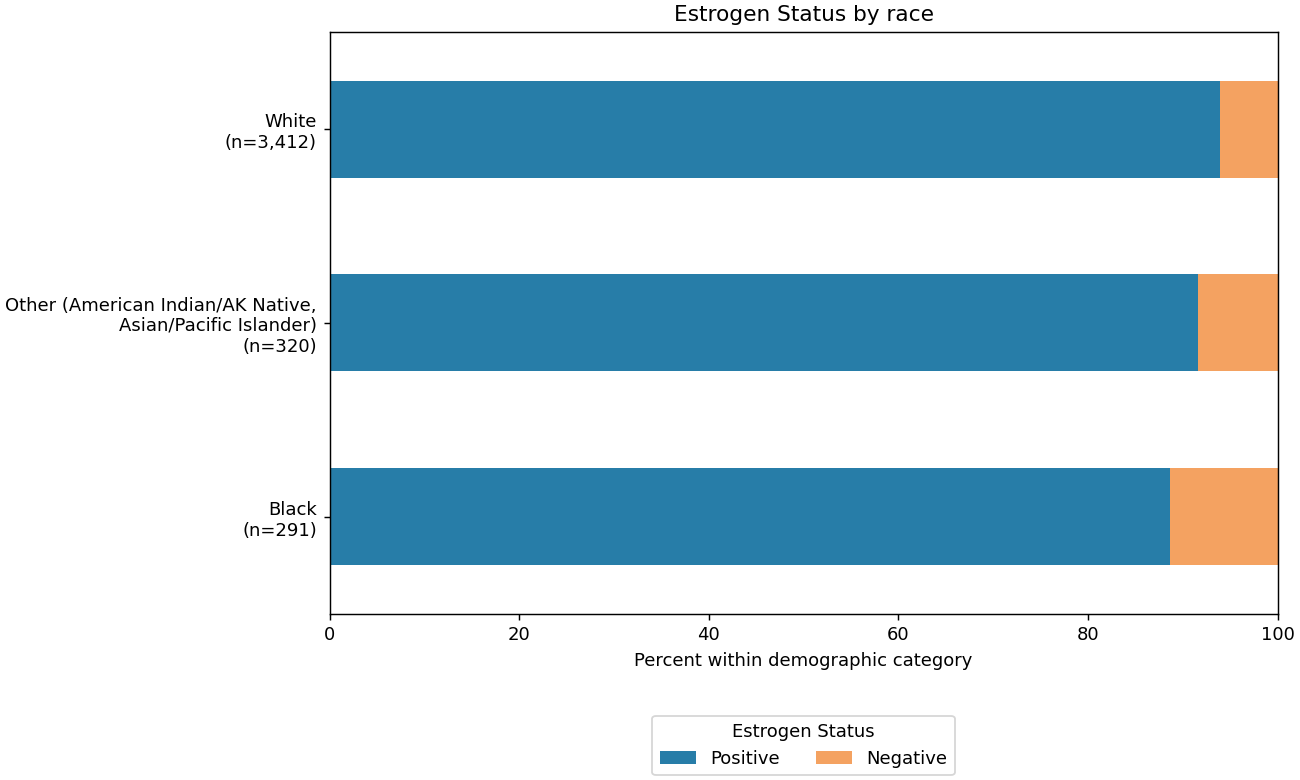

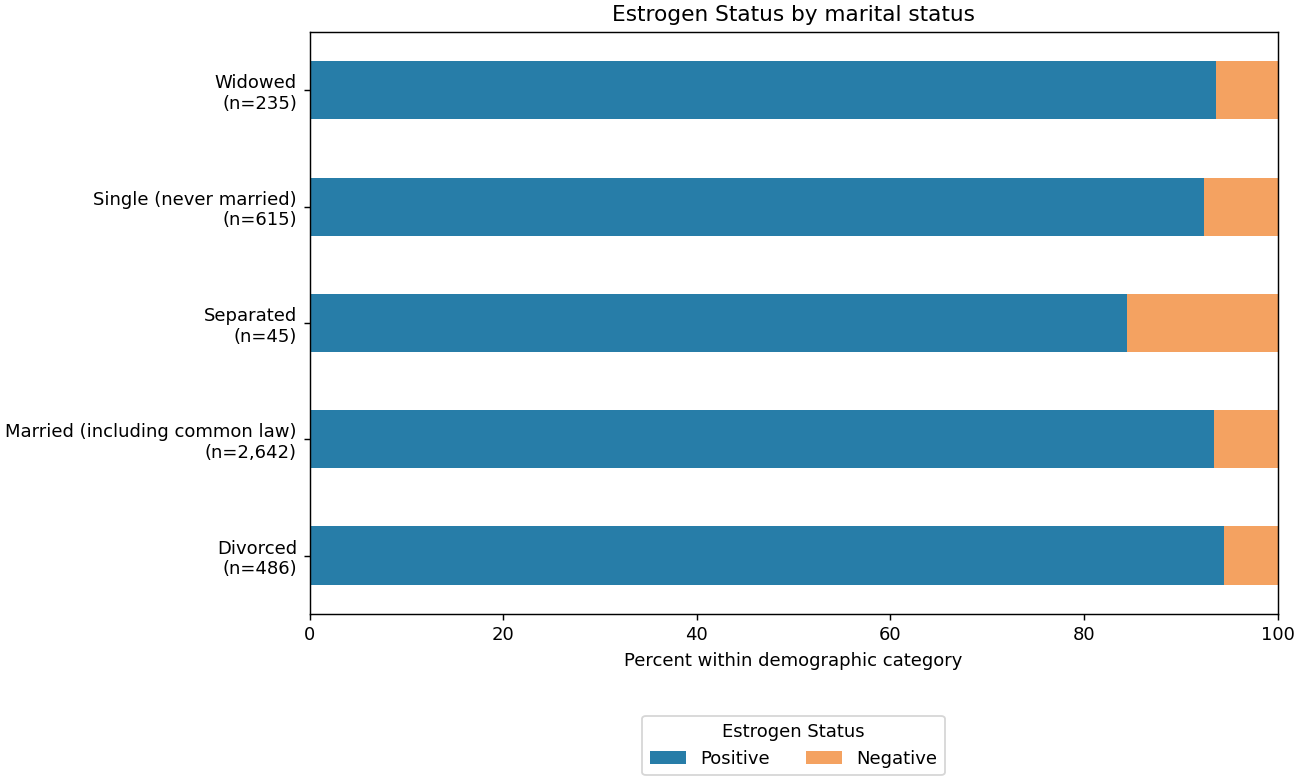

In [8]:
for demographic in ["Age", *DEMOGRAPHICS]:
    display_figure(figures[('Estrogen Status', demographic)])
    plt.close(figures[('Estrogen Status', demographic)])

### Progesterone Status

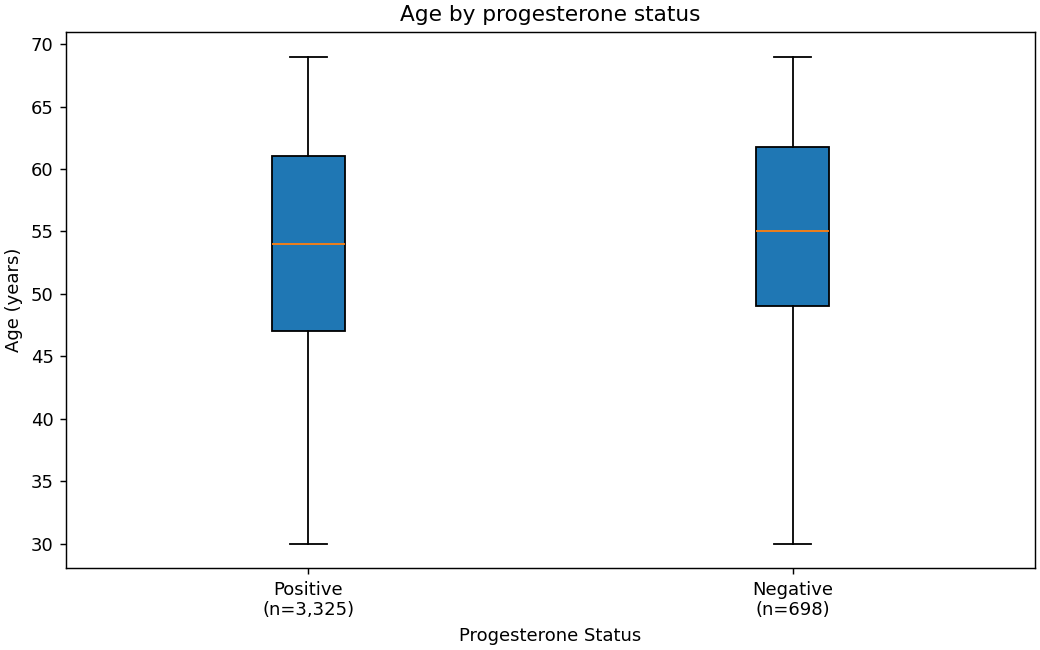

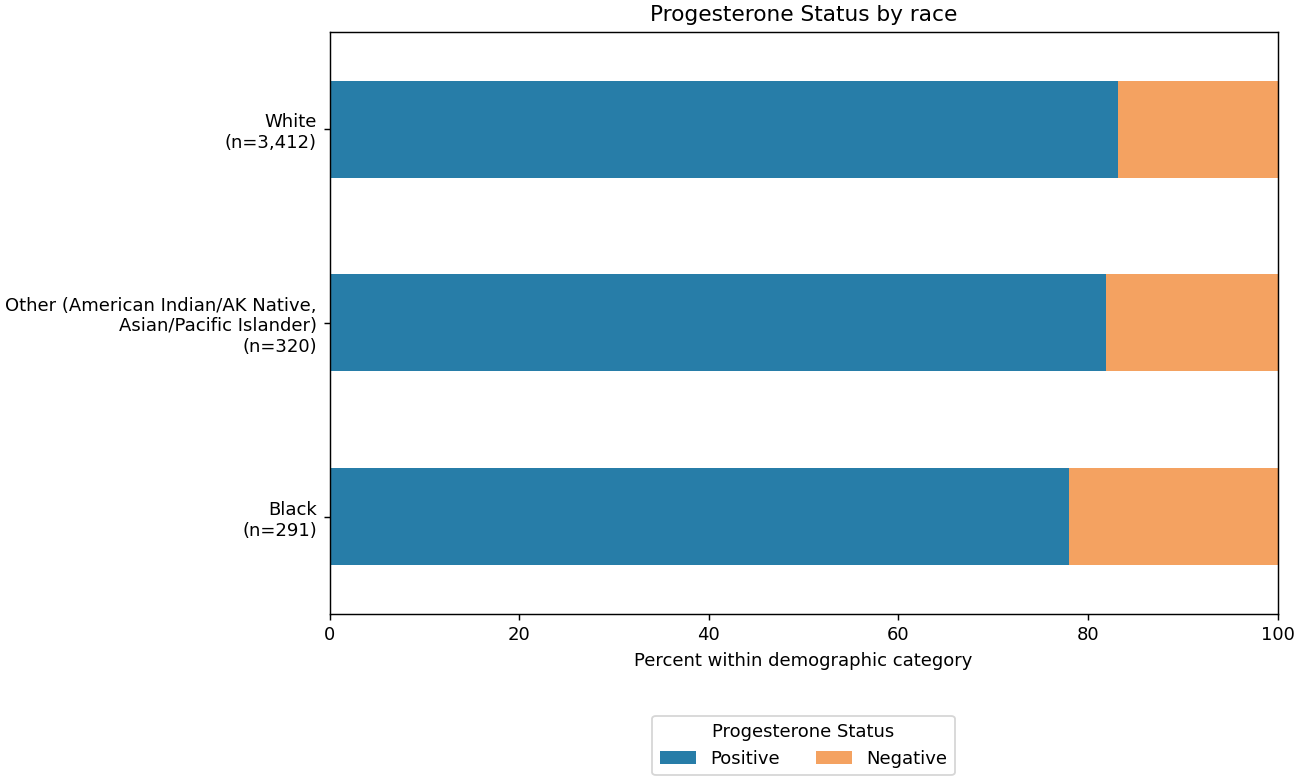

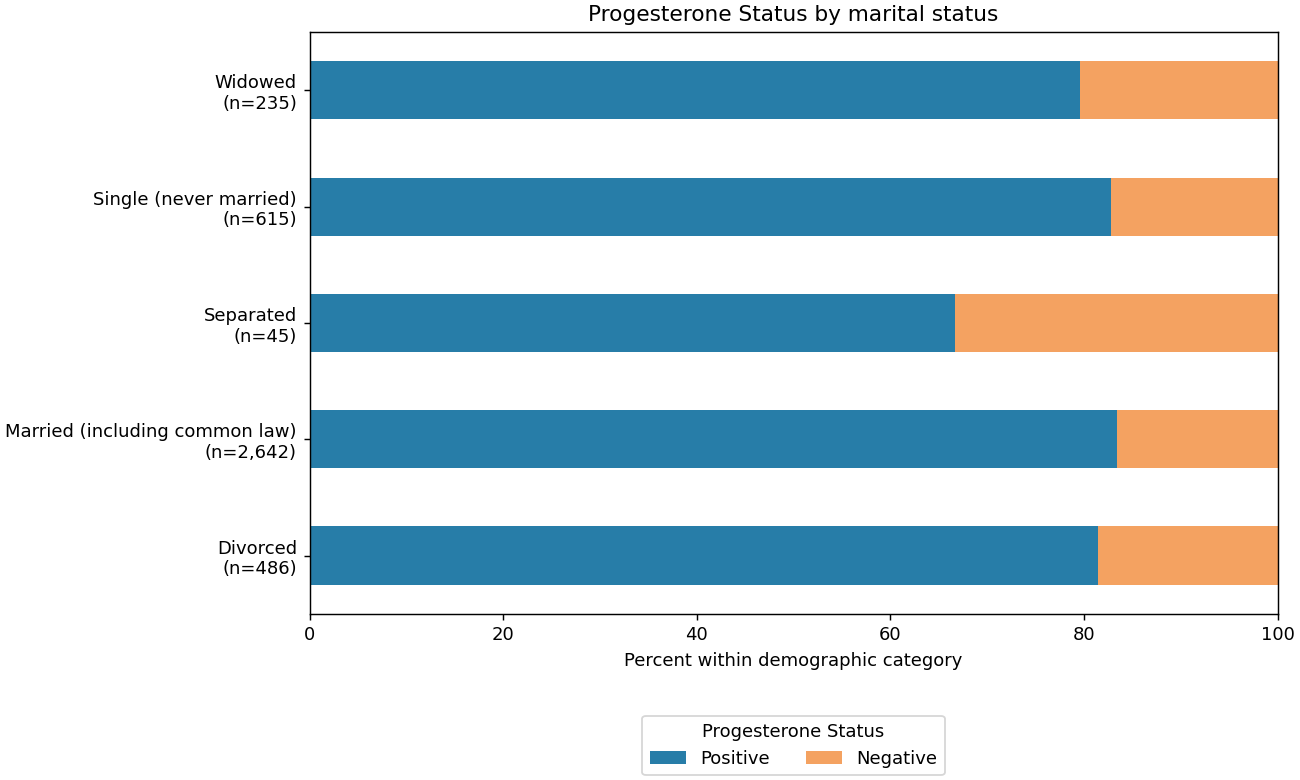

In [9]:
for demographic in ["Age", *DEMOGRAPHICS]:
    display_figure(figures[('Progesterone Status', demographic)])
    plt.close(figures[('Progesterone Status', demographic)])

### Receptor Group

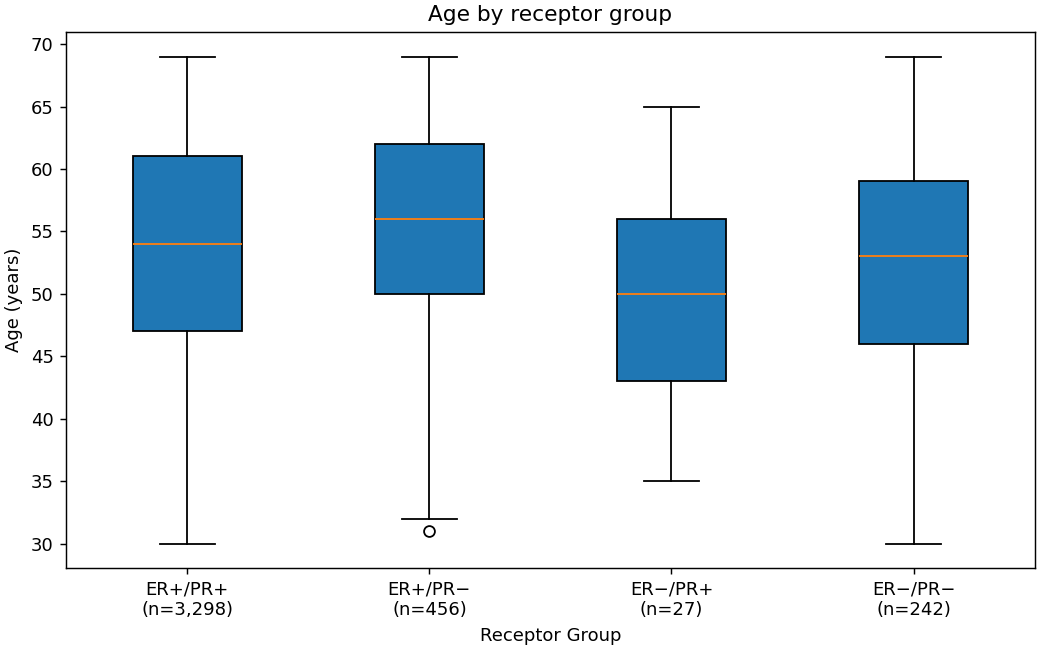

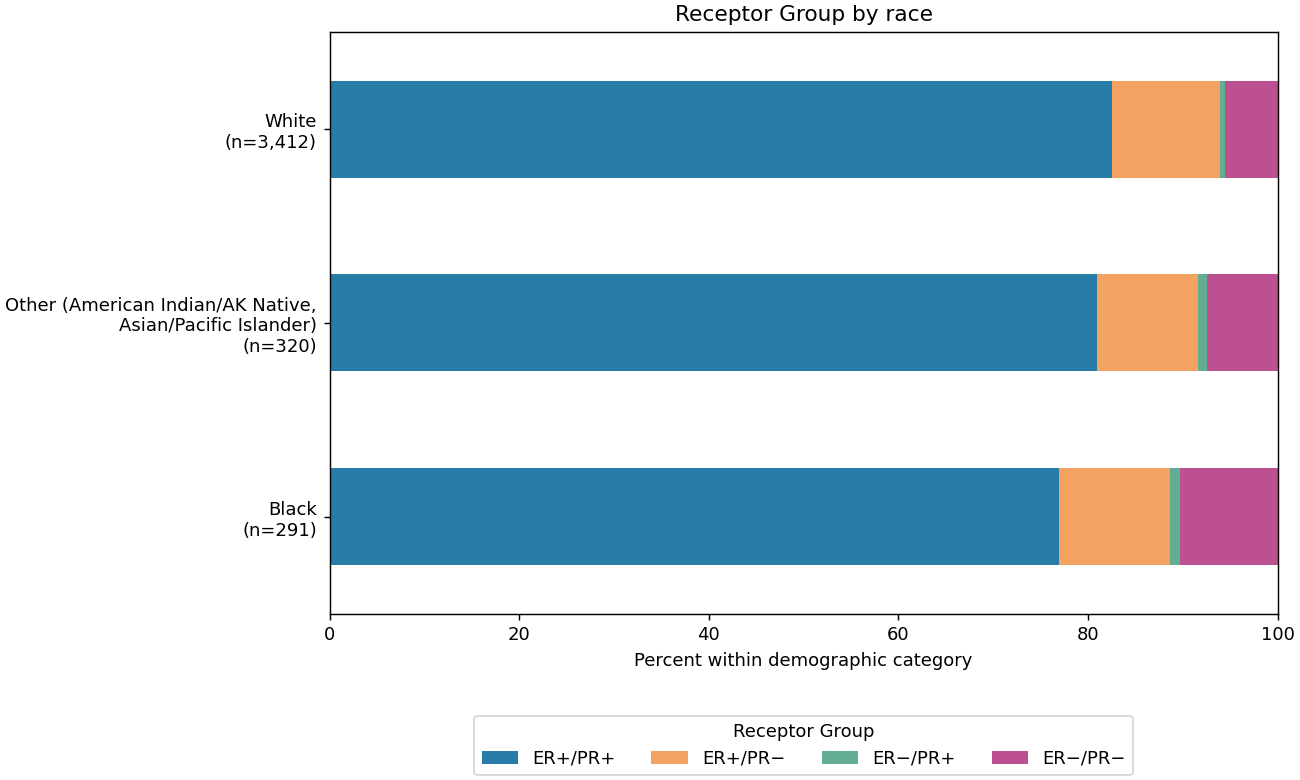

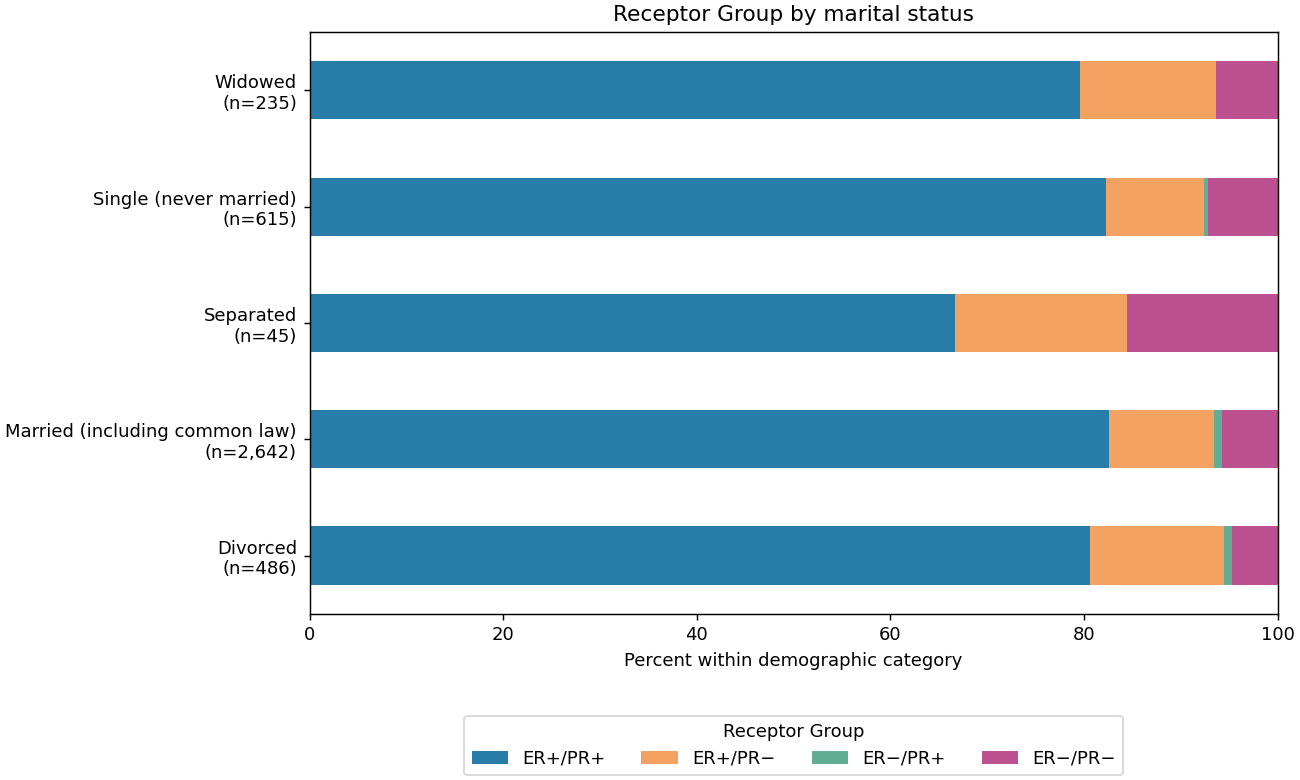

In [10]:
for demographic in ["Age", *DEMOGRAPHICS]:
    display_figure(figures[('Receptor Group', demographic)])
    plt.close(figures[('Receptor Group', demographic)])

## 4. Association tests

The table includes sample size, raw and adjusted p-values, effect sizes, and expected-cell diagnostics. Omnibus tests do not identify specific pairs of demographic categories that differ.

In [11]:
display(tests)
display(Markdown("**Comparisons with BH-adjusted p < 0.05**"))
display(tests.loc[tests["p_adjusted_bh"] < 0.05, ["receptor", "demographic", "effect", "effect_name", "p_adjusted_bh"]])

,receptor,demographic,test,n,statistic,p_value,effect,effect_name,minimum_expected,sparse,p_adjusted_bh
0,Estrogen Status,Age,Mann–Whitney U,4023,4.397810e+05,0.000398,-0.128996,rank-biserial (first alphabetical group minus ...,NaN,False,0.001792
1,Estrogen Status,Race,Pearson chi-square,4023,1.339438e+01,0.001234,0.057701,Cramér's V,19.457867,False,0.003703
2,Estrogen Status,Marital Status,Pearson chi-square; fixed-margin Monte Carlo p...,4023,7.685616e+00,0.098795,0.043708,Cramér's V,3.008949,True,0.099382
3,Progesterone Status,Age,Mann–Whitney U,4023,1.206372e+06,0.099382,0.039595,rank-biserial (first alphabetical group minus ...,NaN,False,0.099382
4,Progesterone Status,Race,Pearson chi-square,4023,5.030964e+00,0.080824,0.035363,Cramér's V,50.489187,False,0.099382
5,Progesterone Status,Marital Status,Pearson chi-square,4023,1.102732e+01,0.026259,0.052355,Cramér's V,7.807606,False,0.059082
6,Receptor Group,Age,Kruskal–Wallis,4023,2.903874e+01,0.000002,0.006479,epsilon-squared,NaN,False,0.000020
7,Receptor Group,Race,Pearson chi-square; fixed-margin Monte Carlo p...,4023,1.382050e+01,0.033898,0.041445,Cramér's V,1.953020,True,0.061017
8,Receptor Group,Marital Status,Pearson chi-square; fixed-margin Monte Carlo p...,4023,2.128354e+01,0.053347,0.041994,Cramér's V,0.302013,True,0.080021


**Comparisons with BH-adjusted p < 0.05**

,receptor,demographic,effect,effect_name,p_adjusted_bh
0,Estrogen Status,Age,-0.128996,rank-biserial (first alphabetical group minus ...,0.001792
1,Estrogen Status,Race,0.057701,Cramér's V,0.003703
6,Receptor Group,Age,0.006479,epsilon-squared,0.000020


## 5. Findings and interpretation

### Findings in this cohort

Analyzed **4,023 records** from `dataset/seer_breast_cancer_cleaned.csv`.

### Data checks

Age range: 30–69; median 54.0 years. Missing values in analysis fields: 0. Exact duplicate rows: 0. Duplicates are retained because no patient identifier establishes whether they are duplicate patients.

### Main patterns

- ER+/PR+: 3,298 (82.0% of all records).
- ER+/PR−: 456 (11.3% of all records).
- ER−/PR+: 27 (0.7% of all records).
- ER−/PR−: 242 (6.0% of all records).
- Age by Estrogen Status: Negative: median 53.0, IQR 46.0–59.0, n=269; Positive: median 54.0, IQR 47.0–62.0, n=3,754.
- Age by Progesterone Status: Negative: median 55.0, IQR 49.0–61.8, n=698; Positive: median 54.0, IQR 47.0–61.0, n=3,325.
- Age by Receptor Group: ER+/PR+: median 54.0, IQR 47.0–61.0, n=3,298; ER+/PR−: median 56.0, IQR 50.0–62.0, n=456; ER−/PR+: median 50.0, IQR 43.0–56.0, n=27; ER−/PR−: median 53.0, IQR 46.0–59.0, n=242.
- ER-negative percentages within race: Black: 11.3% (n=291); Other (American Indian/AK Native, Asian/Pacific Islander): 8.4% (n=320); White: 6.1% (n=3,412).
- ER-negative percentages within marital status: Divorced: 5.6% (n=486); Married (including common law): 6.5% (n=2,642); Separated: 15.6% (n=45); Single (never married): 7.6% (n=615); Widowed: 6.4% (n=235).
- Interpret adjusted p-values alongside the reported effect sizes. A nonsignificant result does not establish that groups are equivalent.

### Association tests

Nine omnibus comparisons were adjusted together using Benjamini–Hochberg false-discovery-rate correction. These are unadjusted associations, not causal effects.

| Receptor | Demographic | Test | Effect | Raw p | BH-adjusted p |
|---|---|---|---|---|---|
| Estrogen Status | Age | Mann–Whitney U | rank-biserial (first alphabetical group minus second): -0.1290 | 0.0003982 | 0.001792 |
| Estrogen Status | Race | Pearson chi-square | Cramér's V: 0.0577 | 0.001234 | 0.003703 |
| Estrogen Status | Marital Status | Pearson chi-square; fixed-margin Monte Carlo p (20,000 draws) | Cramér's V: 0.0437 | 0.0988 | 0.09938 |
| Progesterone Status | Age | Mann–Whitney U | rank-biserial (first alphabetical group minus second): 0.0396 | 0.09938 | 0.09938 |
| Progesterone Status | Race | Pearson chi-square | Cramér's V: 0.0354 | 0.08082 | 0.09938 |
| Progesterone Status | Marital Status | Pearson chi-square | Cramér's V: 0.0524 | 0.02626 | 0.05908 |
| Receptor Group | Age | Kruskal–Wallis | epsilon-squared: 0.0065 | 2.198e-06 | 1.978e-05 |
| Receptor Group | Race | Pearson chi-square; fixed-margin Monte Carlo p (20,000 draws) | Cramér's V: 0.0414 | 0.0339 | 0.06102 |
| Receptor Group | Marital Status | Pearson chi-square; fixed-margin Monte Carlo p (20,000 draws) | Cramér's V: 0.0420 | 0.05335 | 0.08002 |

Comparisons with BH-adjusted p < 0.05: Estrogen Status versus Age; Estrogen Status versus Race; Receptor Group versus Age.

### Interpretation and limitations

Age boxplots show medians and interquartile ranges; categorical charts use percentages within each demographic category and display denominators. Consult the exported count and percentage tables for individual cells. Omnibus tests do not identify which category pairs differ; no post-hoc pairwise claims are made.

Mann–Whitney tests compare age distributions, not strictly medians. Signed rank-biserial effects use the first alphabetical receptor group minus the second (Negative minus Positive). Joint-group age tests use Kruskal–Wallis with epsilon-squared. Categorical effects use uncorrected Cramér's V. Sparse tables use fixed-margin Monte Carlo Pearson statistics with 20,000 draws and seed 20261008; their p-values have simulation uncertainty and minimum resolution 1/20,001.

The receptor groups and tests overlap, so comparisons are dependent; adjusted p-values should be treated as exploratory. Small receptor and demographic subgroups limit precision. Race categories are broad, and the supplied 'Other' category combines distinct populations. Race and marital status are recorded categories, not biological explanations. HER2 status is unavailable, so ER−/PR− must not be called triple-negative disease.

Results describe this supplied cohort only. No sampling weights, patient identifiers, or source inclusion criteria are available here. Independence of records is assumed. The analysis does not adjust for clinical characteristics, assess survival, establish causality, or support individual treatment recommendations.



## 6. Verification

These checks verify that group totals and table denominators match the cohort and that adjusted p-values are valid.

In [12]:
assert len(tests) == 9
assert ages.groupby("receptor")["n"].sum().eq(len(df)).all()
assert receptor_summary["count"].sum() == len(df)
assert all(table.to_numpy().sum() == len(df) for table in tables.values())
assert tests["p_adjusted_bh"].between(0, 1).all()
assert (tests["p_adjusted_bh"] >= tests["p_value"] - 1e-12).all()
assert len(figures) == 9
print("Verified: counts, denominators, nine charts, and adjusted p-values.")

Verified: counts, denominators, nine charts, and adjusted p-values.


## 7. Streamlit integration and optional export

`load_data`, `summarize`, and `make_figures` provide the interface for a future Streamlit page. The complete module and standalone Streamlit page are included below as source strings. Set `EXPORT_FILES = True` to export a runnable app, a copy of the cleaned CSV, and analysis outputs into `week5_export/`. Export is disabled by default so rerunning the notebook only displays results.

After export, install the supplied requirements and run `streamlit run week5_export/streamlit_app.py` from the project directory. The app uses the same statistical methods shown above.

In [13]:
ANALYSIS_MODULE_SOURCE = '"""Descriptive, unadjusted receptor/demographic associations in the supplied cohort."""\nfrom pathlib import Path\nimport argparse\nimport json\nimport textwrap\nimport numpy as np\nimport pandas as pd\nfrom scipy import stats\nimport matplotlib\nmatplotlib.use("Agg")\nimport matplotlib.pyplot as plt\n\nROOT = Path(__file__).resolve().parents[1]\nRECEPTORS = ["Estrogen Status", "Progesterone Status", "Receptor Group"]\nDEMOGRAPHICS = ["Race", "Marital Status"]\nGROUP_ORDER = ["ER+/PR+", "ER+/PR−", "ER−/PR+", "ER−/PR−"]\n\n\ndef load_data(path=ROOT / "dataset/seer_breast_cancer_cleaned.csv"):\n    df = pd.read_csv(path)\n    required = ["Age", *DEMOGRAPHICS, "Estrogen Status", "Progesterone Status"]\n    missing = set(required) - set(df.columns)\n    if missing:\n        raise ValueError(f"Missing columns: {sorted(missing)}")\n    for col in required[1:]:\n        df[col] = df[col].astype("string").str.strip().replace("", pd.NA)\n    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")\n    if ((df["Age"] < 0) | (df["Age"] > 120)).any():\n        raise ValueError("Age outside plausible range 0–120.")\n    for col in ["Estrogen Status", "Progesterone Status"]:\n        unexpected = set(df[col].dropna().unique()) - {"Positive", "Negative"}\n        if unexpected:\n            raise ValueError(f"Unexpected {col}: {unexpected}")\n    er = df["Estrogen Status"].map({"Positive": "+", "Negative": "−"})\n    pr = df["Progesterone Status"].map({"Positive": "+", "Negative": "−"})\n    df["Receptor Group"] = "ER" + er + "/PR" + pr\n    return df\n\n\ndef bh_adjust(pvalues):\n    p = np.asarray(pvalues, dtype=float)\n    order = np.argsort(p)\n    adjusted = np.minimum.accumulate((p[order] * len(p) / np.arange(1, len(p)+1))[::-1])[::-1]\n    result = np.empty_like(p)\n    result[order] = np.minimum(adjusted, 1)\n    return result\n\n\ndef summarize(df):\n    quality = pd.DataFrame({"missing": df.isna().sum(), "unique_values": df.nunique()})\n    ages, tables, tests = [], {}, []\n    for receptor in RECEPTORS:\n        subset = df.dropna(subset=[receptor, "Age"])\n        groups = [g["Age"].to_numpy() for _, g in subset.groupby(receptor, sort=True)]\n        for label, group in subset.groupby(receptor, sort=True):\n            age = group["Age"]\n            ages.append(dict(receptor=receptor, group=label, n=len(age), mean=age.mean(),\n                             sd=age.std(), median=age.median(), q1=age.quantile(.25), q3=age.quantile(.75),\n                             minimum=age.min(), maximum=age.max()))\n        if len(groups) < 2 or any(len(g) == 0 for g in groups):\n            raise ValueError(f"Insufficient groups for {receptor}")\n        if len(groups) == 2:\n            result = stats.mannwhitneyu(*groups, alternative="two-sided", method="asymptotic")\n            effect = 2 * result.statistic / (len(groups[0])*len(groups[1])) - 1\n            effect_name = "rank-biserial (first alphabetical group minus second)"\n            method = "Mann–Whitney U"\n        else:\n            result = stats.kruskal(*groups)\n            effect = max(0, (result.statistic-len(groups)+1)/(len(subset)-len(groups)))\n            effect_name = "epsilon-squared"\n            method = "Kruskal–Wallis"\n        tests.append(dict(receptor=receptor, demographic="Age", test=method, n=len(subset),\n                          statistic=result.statistic, p_value=result.pvalue, effect=effect,\n                          effect_name=effect_name, minimum_expected=np.nan, sparse=False))\n        for demographic in DEMOGRAPHICS:\n            table = pd.crosstab(df[demographic], df[receptor])\n            chi2, p, _, expected = stats.chi2_contingency(table)\n            sparse = bool((expected < 5).any())\n            # Fixed-margin Monte Carlo avoids unreliable asymptotics for sparse cells.\n            if sparse:\n                rng = np.random.default_rng(20261008)\n                simulations = stats.random_table.rvs(table.sum(axis=1).to_numpy(),\n                    table.sum(axis=0).to_numpy(), size=20000, random_state=rng)\n                simulated_chi2 = ((simulations-expected)**2/expected).sum(axis=(1,2))\n                p = (1 + (simulated_chi2 >= chi2-1e-10).sum()) / 20001\n            n = int(table.to_numpy().sum())\n            effect = np.sqrt(chi2/(n*min(table.shape[0]-1, table.shape[1]-1)))\n            tests.append(dict(receptor=receptor, demographic=demographic,\n                test="Pearson chi-square" + ("; fixed-margin Monte Carlo p (20,000 draws)" if sparse else ""),\n                n=n, statistic=chi2, p_value=p, effect=effect, effect_name="Cramér\'s V",\n                minimum_expected=expected.min(), sparse=sparse))\n            tables[(receptor, demographic)] = table\n    tests = pd.DataFrame(tests)\n    tests["p_adjusted_bh"] = bh_adjust(tests.p_value)\n    return quality, pd.DataFrame(ages), tables, tests\n\n\ndef make_figures(df):\n    figures = {}\n    for receptor in RECEPTORS:\n        order = GROUP_ORDER if receptor == "Receptor Group" else ["Positive", "Negative"]\n        order = [x for x in order if (df[receptor] == x).any()]\n        fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")\n        arrays = [df.loc[df[receptor] == x, "Age"].dropna() for x in order]\n        ax.boxplot(arrays, tick_labels=[f"{x}\\n(n={len(a):,})" for x,a in zip(order, arrays)], patch_artist=True)\n        ax.set(title=f"Age by {receptor.lower()}", ylabel="Age (years)", xlabel=receptor)\n        figures[(receptor, "Age")] = fig\n        for demographic in DEMOGRAPHICS:\n            counts = pd.crosstab(df[demographic], df[receptor]).reindex(columns=order, fill_value=0)\n            percentages = counts.div(counts.sum(axis=1), axis=0)*100\n            fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")\n            percentages.plot.barh(stacked=True, ax=ax, color=["#277da8", "#f4a261", "#63ad95", "#bc5090"][:len(order)])\n            labels = [f"{textwrap.fill(str(x), 35)}\\n(n={int(n):,})" for x,n in zip(counts.index, counts.sum(axis=1))]\n            ax.set_yticks(range(len(labels)), labels=labels)\n            ax.set(xlim=(0,100), xlabel="Percent within demographic category", ylabel="",\n                   title=f"{receptor} by {demographic.lower()}")\n            ax.legend(title=receptor, loc="upper center", bbox_to_anchor=(.5,-.16), ncol=min(4,len(order)))\n            figures[(receptor, demographic)] = fig\n    return figures\n\n\ndef slug(text):\n    return text.lower().replace(" ", "_")\n\n\ndef write_report(df, ages, tests, output):\n    counts = df["Receptor Group"].value_counts().reindex(GROUP_ORDER, fill_value=0)\n    lines = ["# Hormone receptor status and demographic patterns", "",\n        f"Analyzed **{len(df):,} records** from `dataset/seer_breast_cancer_cleaned.csv`.", "",\n        "## Data checks", "",\n        f"Age range: {df.Age.min():.0f}–{df.Age.max():.0f}; median {df.Age.median():.1f} years. "\n        f"Missing values in analysis fields: {int(df[[\'Age\', *DEMOGRAPHICS, \'Estrogen Status\', \'Progesterone Status\']].isna().sum().sum())}. "\n        f"Exact duplicate rows: {int(df.drop(columns=\'Receptor Group\').duplicated().sum())}. Duplicates are retained because no patient identifier establishes whether they are duplicate patients.",\n        "", "## Main patterns", ""]\n    for group,n in counts.items():\n        lines.append(f"- {group}: {n:,} ({100*n/len(df):.1f}% of all records).")\n    for receptor in RECEPTORS:\n        rows = ages[ages.receptor == receptor]\n        summary = "; ".join(f"{r.group}: median {r.median:.1f}, IQR {r.q1:.1f}–{r.q3:.1f}, n={r.n:,}" for r in rows.itertuples())\n        lines.append(f"- Age by {receptor}: {summary}.")\n    for demographic in DEMOGRAPHICS:\n        table = pd.crosstab(df[demographic], df["Estrogen Status"])\n        rates = 100*table["Negative"]/table.sum(axis=1)\n        lines.append(f"- ER-negative percentages within {demographic.lower()}: " + "; ".join(f"{label}: {value:.1f}% (n={int(table.loc[label].sum()):,})" for label,value in rates.items()) + ".")\n    lines.append("- Interpret adjusted p-values alongside the reported effect sizes. A nonsignificant result does not establish that groups are equivalent.")\n    lines += ["", "## Association tests", "", "Nine omnibus comparisons were adjusted together using Benjamini–Hochberg false-discovery-rate correction. These are unadjusted associations, not causal effects.", "",\n        "| Receptor | Demographic | Test | Effect | Raw p | BH-adjusted p |", "|---|---|---|---|---|---|"]\n    for r in tests.itertuples():\n        lines.append(f"| {r.receptor} | {r.demographic} | {r.test} | {r.effect_name}: {r.effect:.4f} | {r.p_value:.4g} | {r.p_adjusted_bh:.4g} |")\n    significant = tests[tests.p_adjusted_bh < .05]\n    lines += ["", "Comparisons with BH-adjusted p < 0.05: " + ("; ".join(f"{r.receptor} versus {r.demographic}" for r in significant.itertuples()) or "none") + ".", "",\n        "## Interpretation and limitations", "",\n        "Age boxplots show medians and interquartile ranges; categorical charts use percentages within each demographic category and display denominators. Consult the exported count and percentage tables for individual cells. Omnibus tests do not identify which category pairs differ; no post-hoc pairwise claims are made.", "",\n        "Mann–Whitney tests compare age distributions, not strictly medians. Signed rank-biserial effects use the first alphabetical receptor group minus the second (Negative minus Positive). Joint-group age tests use Kruskal–Wallis with epsilon-squared. Categorical effects use uncorrected Cramér\'s V. Sparse tables use fixed-margin Monte Carlo Pearson statistics with 20,000 draws and seed 20261008; their p-values have simulation uncertainty and minimum resolution 1/20,001.", "",\n        "The receptor groups and tests overlap, so comparisons are dependent; adjusted p-values should be treated as exploratory. Small receptor and demographic subgroups limit precision. Race categories are broad, and the supplied \'Other\' category combines distinct populations. Race and marital status are recorded categories, not biological explanations. HER2 status is unavailable, so ER−/PR− must not be called triple-negative disease.", "",\n        "Results describe this supplied cohort only. No sampling weights, patient identifiers, or source inclusion criteria are available here. Independence of records is assumed. The analysis does not adjust for clinical characteristics, assess survival, establish causality, or support individual treatment recommendations.", "",\n        "## Reproduction and Streamlit", "", "Run `python -m analysis.hormone_demographics` to regenerate tables, figures, and this report. Run `streamlit run streamlit_app.py` to inspect the reusable analysis in a standalone page. The module exposes `load_data`, `summarize`, and `make_figures` for integration into a future multipage app."]\n    (output/"report.md").write_text("\\n".join(lines)+"\\n")\n\n\ndef run(data_path=ROOT/"dataset/seer_breast_cancer_cleaned.csv", output=ROOT/"outputs/hormone_demographics"):\n    output = Path(output)\n    output.mkdir(parents=True, exist_ok=True)\n    df = load_data(data_path)\n    quality, ages, tables, tests = summarize(df)\n    quality.to_csv(output/"data_quality.csv")\n    ages.to_csv(output/"age_summary.csv", index=False)\n    tests.to_csv(output/"association_tests.csv", index=False)\n    df["Receptor Group"].value_counts().reindex(GROUP_ORDER, fill_value=0).rename("count").to_csv(output/"receptor_groups.csv")\n    for (receptor, demographic), table in tables.items():\n        name = f"{slug(receptor)}_by_{slug(demographic)}"\n        table.to_csv(output/f"{name}_counts.csv")\n        (table.div(table.sum(axis=1), axis=0)*100).to_csv(output/f"{name}_percent.csv")\n    for (receptor, demographic), fig in make_figures(df).items():\n        fig.savefig(output/f"{slug(receptor)}_by_{slug(demographic)}.png", dpi=160)\n        plt.close(fig)\n    write_report(df, ages, tests, output)\n    (output/"metadata.json").write_text(json.dumps({"input":str(data_path),"records":len(df),"monte_carlo_draws":20000,"seed":20261008}, indent=2)+"\\n")\n    return df, ages, tests\n\nif __name__ == "__main__":\n    parser = argparse.ArgumentParser(description=__doc__)\n    parser.add_argument("--data", type=Path, default=ROOT/"dataset/seer_breast_cancer_cleaned.csv")\n    parser.add_argument("--output", type=Path, default=ROOT/"outputs/hormone_demographics")\n    args = parser.parse_args()\n    run(args.data, args.output)\n    print(f"Analysis saved to {args.output}")\n'

STREAMLIT_APP_SOURCE = '"""Standalone page; analysis functions can also be used in a multipage app."""\nimport matplotlib.pyplot as plt\nimport streamlit as st\nfrom analysis.hormone_demographics import load_data, summarize, make_figures, RECEPTORS\n\nst.set_page_config(page_title="Hormone receptor and demographic patterns", layout="wide")\nst.title("Hormone receptor status and demographic patterns")\nst.caption("Exploratory associations in the supplied breast cancer cohort.")\ndf = load_data()\nquality, ages, tables, tests = summarize(df)\nst.metric("Cohort records", f"{len(df):,}")\nst.info("ER and PR are available; HER2 is unavailable. ER−/PR− does not establish triple-negative disease.")\nreceptor = st.selectbox("Receptor grouping", RECEPTORS)\nfigures = make_figures(df)\nfor (grouping, demographic), fig in figures.items():\n    if grouping == receptor:\n        st.pyplot(fig)\n    plt.close(fig)\nst.subheader("Age summary")\nst.dataframe(ages[ages.receptor == receptor], hide_index=True)\nfor (grouping, demographic), table in tables.items():\n    if grouping == receptor:\n        with st.expander(f"{demographic}: counts and within-category percentages"):\n            st.dataframe(table)\n            st.dataframe((table.div(table.sum(axis=1), axis=0)*100).round(2))\nst.subheader("Association tests")\nst.caption("BH correction covers all nine comparisons. Effects are unadjusted; omnibus tests do not establish individual pairwise differences.")\nst.dataframe(tests, hide_index=True)\nst.download_button("Download association tests", tests.to_csv(index=False), "association_tests.csv", "text/csv")\nwith st.expander("Data quality and interpretation"):\n    st.dataframe(quality)\n    st.write("Small subgroups limit precision. Broad race categories combine distinct populations. No sampling weights or patient identifiers are supplied; records are assumed independent. Associations do not establish causality and are not adjusted for clinical characteristics. Sparse tables use fixed-margin Monte Carlo p-values (20,000 draws).")\n'

REQUIREMENTS = 'pandas>=2.2,<3\nnumpy>=1.26,<3\nscipy>=1.12,<2\nmatplotlib>=3.9,<4\nstreamlit>=1.40,<2\n'

EXPORT_FILES = False
if EXPORT_FILES:
    destination = ROOT / "week5_export"
    (destination / "analysis").mkdir(parents=True, exist_ok=True)
    (destination / "dataset").mkdir(exist_ok=True)
    (destination / "analysis/__init__.py").write_text("", encoding="utf-8")
    (destination / "analysis/hormone_demographics.py").write_text(ANALYSIS_MODULE_SOURCE, encoding="utf-8")
    (destination / "streamlit_app.py").write_text(STREAMLIT_APP_SOURCE, encoding="utf-8")
    (destination / "requirements.txt").write_text(REQUIREMENTS, encoding="utf-8")
    (destination / "dataset/seer_breast_cancer_cleaned.csv").write_bytes(DATA_PATH.read_bytes())
    namespace = {"__name__": "week5_export_module", "__file__": str(destination / "analysis/hormone_demographics.py")}
    exec(compile(ANALYSIS_MODULE_SOURCE, namespace["__file__"], "exec"), namespace)
    namespace["run"](destination / "dataset/seer_breast_cancer_cleaned.csv", destination / "outputs/hormone_demographics")
    print("Exported analysis, data, figures, report, and Streamlit app to", destination)
else:
    print("Optional file export disabled. All analysis results are saved in this notebook.")

Optional file export disabled. All analysis results are saved in this notebook.
